In [30]:
import numpy as np
from matplotlib import pyplot as plt 
import cv2

## Lab 3: Image clustering and superpixels

In this lab we are going to explore image clustering and superpixels segmentation. You will be required to complete the following tasks:

1. Implement k-means clustering to assign each pixel of an image to one of K distinct clusters, using colour similarity to determine assignment.
2. Modify your k-means clustering to find superpixels by assigning each pixel of the image to one of K distinct clusters, using both colour and location similarity to determine assignment.
3. Use superpixels to propose regions of interest in the image (we will learn about neural networks that use this information in week 11). 
4. Write a brief report (max 600 words) discussing explaining your implementation and results. Explain your reasoning by referencing the intermediate result figures you generated. 

You may use numpy and matplotlib and opencv for image loading.

### Academic integrity

Every lab submission will be screened for any collusion and/or plagiarism. Breaches of academic integrity will be investigated thoroughly and may result in a zero for the assessment along with interviews with the plagiarism officers at Monash University.

### Late submissions

The default late submission university penalty will apply.

### Lab Instructions and the Use of Generative AI

You may not use any built-in opencv functions for this lab, other than those used for loading/ saving an image, extracting and matching keypoints, and
computing homographies.
* You may use NumPy for array handling, and vectorizing your code (reducing
the number of for-loops) is encouraged.
* You should use Matplotlib to display images and any intermediate results.
* You may use generative AI.

### Grading
Each lab is worth 8%, and there are a number of sections and tasks with their own weighting. A task is only considered complete if you can demonstrate a working program and show an understanding of the underlying concepts. Note that later tasks should reuse code from earlier tasks.

Masks will be provided based on the correctness of the code, the quality of your results, comments indicating you understand your work, and a discussion of tasks provided at the end of the notebook. 

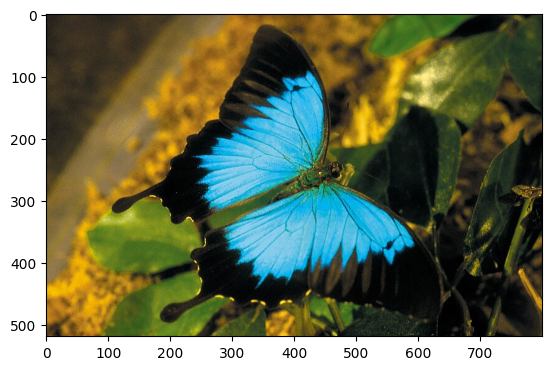

In [31]:
# Load and display image for testing
im = cv2.imread('CSIRO_ScienceImage_3831_Ulysses_Butterfly.jpg')
im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
im = im.astype(np.float32) / 255.0
plt.imshow(im)
plt.show()

### Task 1: Implement K-means from first principles: colour similarity

Fill in the function below to implement the following steps. Your function should accept an image, a variable storing the number of iterations to repeat k-means for, the number of clusters K.
1. Flatten the image into an Nx3 vector of pixels (num pixels x r,g,b colour of pixel)
2. Select K random colour centroids
3. Repeat for n iterations:
   1. Assign each pixel in the vector to a cluster and store the index corresponding to this in a numpy array
   2. Update the centroid locations using the new cluster assignments
   3. Save the total loss at each iteration
4. Convert the cluster index array back into a 2D array the same size as the image, where each pixel contains the corresponding cluster index
5. Create a new quantised image, where each pixel is coloured according to the centroid corresponding to a given cluster index.
6. Return the loss, cluster index image and quantised image
7. Test your function on the sample image provided, and select an appropriate number of iterations 
8. Display the results for a number of choices of K. Use the returned losses to select an appropriate value for K 

In [32]:
def kmeans(im, iters=10, K=3, plot=False):

    # Fixed seed so centroid initialisation is reproducible across runs
    seed = 42
    np.random.seed(seed)

    # Flatten (H, W, C) image into (N, 3) so each row is one pixel in RGB space
    d, w, c = im.shape
    pixels = im.reshape(-1, c)

    # Bootstrap centroids by sampling K distinct pixels at random
    centroids = pixels[np.random.choice(pixels.shape[0], K, replace=False)]

    losses = []  # accumulate loss per iteration to track convergence

    for j in range(iters):

        # Euclidean distance from every pixel to every centroid: shape (N, K)
        dists = np.linalg.norm(pixels[:, np.newaxis] - centroids, axis=2)
        # Each pixel takes the index of its nearest centroid
        cluster_indices = np.argmin(dists, axis=1)

        # Recompute centroids as the mean colour of all pixels in the cluster
        new_centroids = []
        for k in range(K):
            mask = (cluster_indices == k)
            if np.any(mask):
                new_centroids.append(pixels[mask].mean(axis=0))
            else:
                # Re-seed empty cluster with a random pixel to avoid degenerate centroids
                new_centroids.append(pixels[np.random.randint(0, len(pixels))])
        centroids = np.array(new_centroids)

        # Sum of squared distances from each pixel to its assigned centroid
        loss = np.sum((pixels - centroids[cluster_indices])**2)
        losses.append(loss)

        if plot:
            plt.subplot(1,2,1)
            plt.imshow(cluster_indices.reshape(d, w))
            plt.subplot(1,2,2)
            plt.imshow(centroids[cluster_indices].reshape(d, w, c))
            plt.show()

    # Reshape final assignments back to (H, W)
    cluster_idx_image = cluster_indices.reshape(d, w)

    # Build quantised image: replace each pixel with its centroid colour
    quantised_image = (centroids[cluster_indices].reshape(d, w, c) * 255).astype(np.uint8)

    return losses, cluster_idx_image, quantised_image


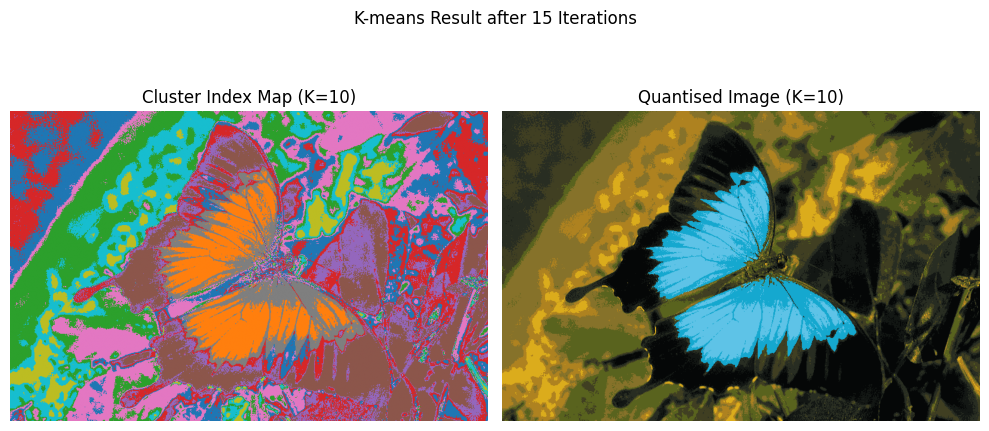

In [33]:
# Test the function: 15 iterations is sufficient (see Figure 3 for convergence evidence)
losses, cluster_idx_image, quantised_image = kmeans(im, iters=15, K=10, plot=False)

plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
plt.imshow(cluster_idx_image, cmap="tab10")
plt.title("Cluster Index Map (K=10)")
plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(quantised_image)
plt.title("Quantised Image (K=10)")
plt.axis("off")
plt.suptitle("K-means Result after 15 Iterations")
plt.tight_layout()
plt.show()


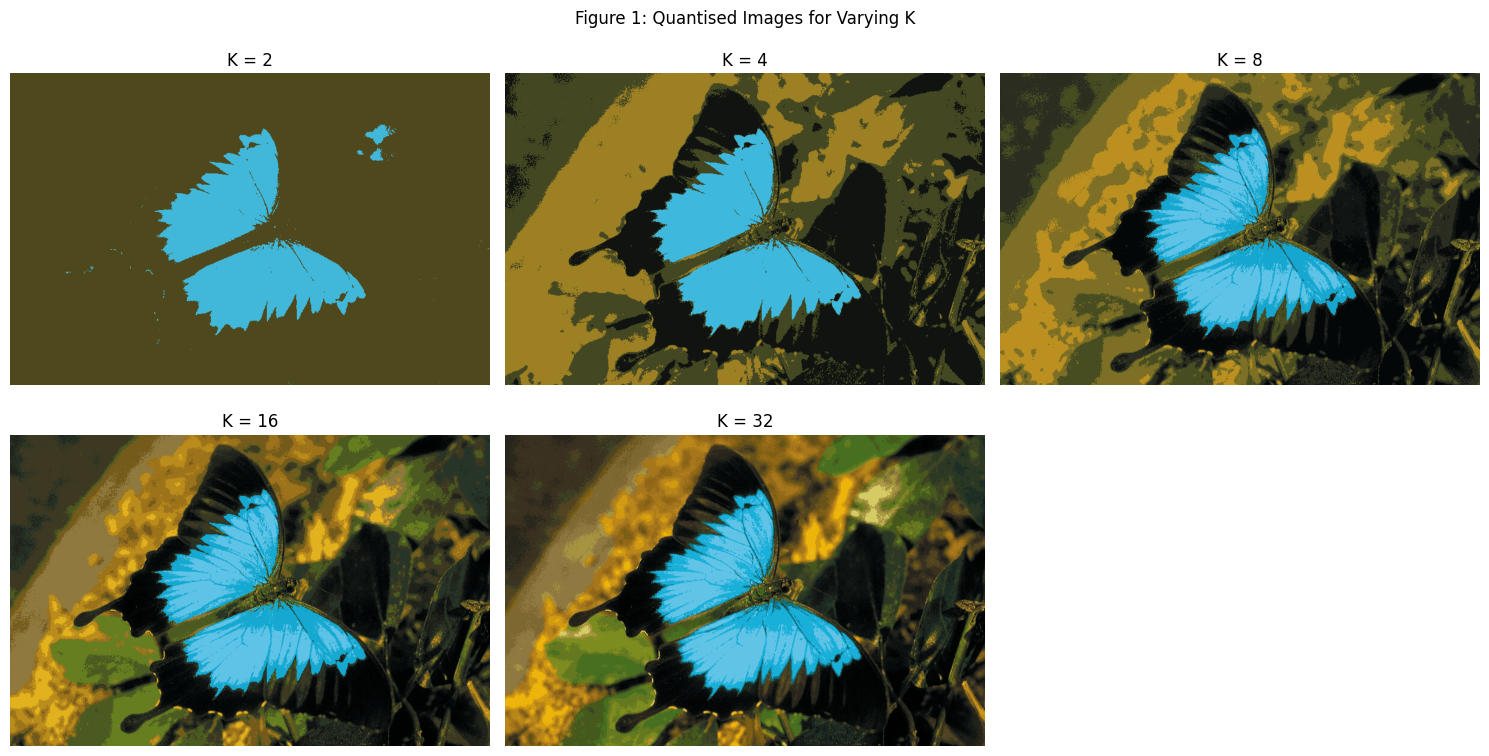

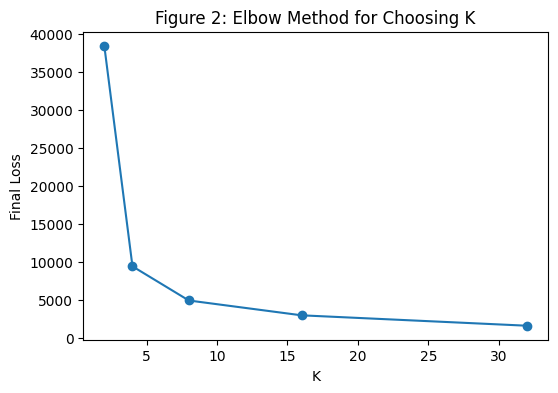

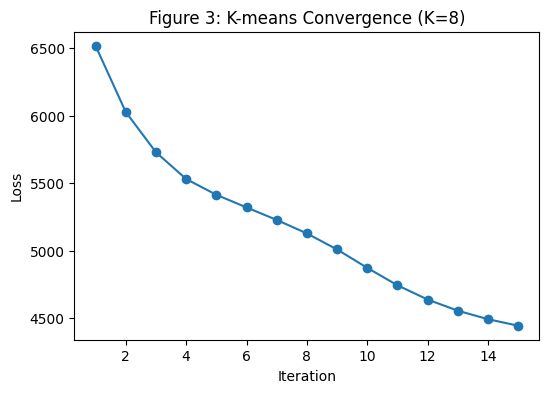

In [34]:
# Figure 1: Quantised images for a range of K values
Ks = [2, 4, 8, 16, 32]
final_losses = []

plt.figure(figsize=(15, 8))
for i, K in enumerate(Ks):
    losses, cluster_img, quant_img = kmeans(im, iters=10, K=K)
    final_losses.append(losses[-1])  # keep only the final converged loss for the elbow plot
    plt.subplot(2, 3, i+1)
    plt.imshow(quant_img)
    plt.title(f"K = {K}")
    plt.axis("off")
plt.suptitle("Figure 1: Quantised Images for Varying K")
plt.tight_layout()
plt.show()

# Figure 2: Elbow method — loss vs K helps identify the optimal K
plt.figure(figsize=(6, 4))
plt.plot(Ks, final_losses, marker="o")
plt.xlabel("K")
plt.ylabel("Final Loss")
plt.title("Figure 2: Elbow Method for Choosing K")
plt.show()

# Figure 3: Convergence plot for K=8 — loss plateaus by ~iteration 6,
# confirming 15 iterations is more than sufficient for convergence
losses, cluster_idx_image, quantised_image = kmeans(im, iters=15, K=8)
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(losses)+1), losses, marker="o")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Figure 3: K-means Convergence (K=8)")
plt.show()


Looking at the graph we can see the elbow occurring at K=8, suggesting that this is the point of diminishing returns, where adding more clusters provides only marginal improvements in image fidelity relative to the increased computational cost.

### Task 2: Modify K-means to cluster based on colour similarity and pixel location and extract superpixels

1. Modify the k_means function above to segment based on colour and pixel location, so that you extract superpixels.

2. Test your implementation by clustering the image into 50 superpixels.

3. Select an appropriate pixel coordinate scaling factor so that you trade-off incorporating colour information into the clustering, while ensuring superpixel continuity (all pixels in a superpixel must remain connected).

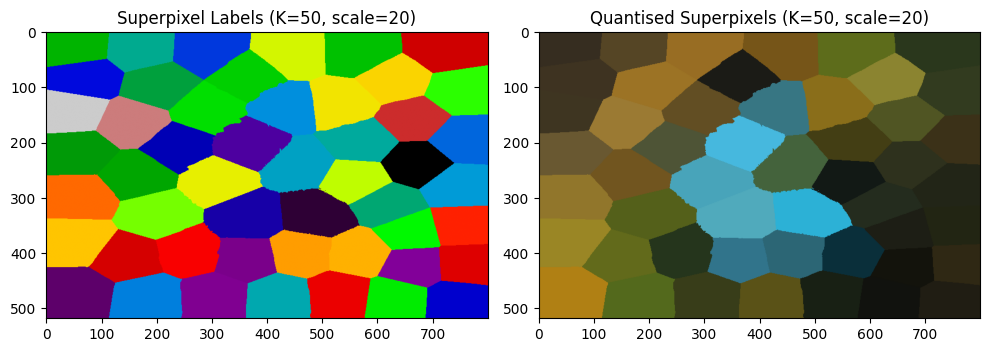

In [35]:
# Use your kmeans function to cluster based on colour and location
def kmeans_superpixels(im, iters=10, K=3, plot=False, spatial_scaling=2.5):
    seed = 42
    np.random.seed(seed)
    
    d, w, c = im.shape
    
    # Create a grid of coordinates (x, y)
    x, y = np.meshgrid(np.arange(w), np.arange(d))
    
    # Normalize coordinates to [0, 1] to match color range
    x_norm = (x / (w - 1)) * spatial_scaling
    y_norm = (y / (d - 1)) * spatial_scaling
    
    # Stack color and spatial features: [R, G, B, X, Y]
    # Shape of features will be (N, 5)
    features = np.dstack((im, x_norm, y_norm)).reshape(-1, 5)
    
    # Select K random feature centroids
    centroids = features[np.random.choice(features.shape[0], K, replace=False)]
    
    losses = []
    
    for j in range(iters):
        # Assign pixels to clusters based on Color + Position
        distances = np.linalg.norm(features[:, np.newaxis] - centroids, axis=2)
        cluster_indices = np.argmin(distances, axis=1)
        
        # Update centroids
        new_centroids = []
        for k in range(K):
            mask = (cluster_indices == k)
            if np.any(mask):
                new_centroids.append(features[mask].mean(axis=0))
            else:
                new_centroids.append(features[np.random.randint(0, len(features))])
        centroids = np.array(new_centroids)
        
        # Calculate loss
        loss = np.sum((features - centroids[cluster_indices])**2)
        losses.append(loss)
        # You may want to visualise the current progress of kmeans for debugging purposes
        if plot:
            # We only use the first 3 dimensions (RGB) for the display image
            rgb_centroids = centroids[:, :3]
            quantised_pixels = rgb_centroids[cluster_indices]
            
            # Reshape for display (scaling back to 0-255)
            # Use a local variable so we don't mess with the loop variables
            current_quant = (quantised_pixels.reshape(d, w, 3) * 255).astype(np.uint8)
            current_clusters = cluster_indices.reshape(d, w)
            
            plt.figure(figsize=(10, 5))
            plt.subplot(1, 2, 1)
            plt.imshow(current_clusters, cmap='nipy_spectral')
            plt.title(f"Superpixel Labels (Iter {j+1})")
            plt.subplot(1, 2, 2)
            plt.imshow(current_quant)
            plt.title(f"Quantized Image (K={K})")
            plt.show()
        
    # Prepare final outputs
    cluster_idx_image = cluster_indices.reshape(d, w)
    
    # Extract just the RGB part (first 3 columns) of the centroids for the image
    rgb_centroids = centroids[:, :3]
    quantised_pixels = rgb_centroids[cluster_indices]
    
    # Convert to uint8 (scaling by 255 since input is 0-1)
    quantised_image = (quantised_pixels.reshape(d, w, 3) * 255).astype(np.uint8)

    return losses, cluster_idx_image, quantised_image

losses, cluster_idx_image, quantised_image = kmeans_superpixels(im, iters=15, K=50, plot=False, spatial_scaling=20)

plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
plt.imshow(cluster_idx_image, cmap="nipy_spectral")
plt.title("Superpixel Labels (K=50, scale=20)")
plt.subplot(1,2,2)
plt.imshow(quantised_image)
plt.title("Quantised Superpixels (K=50, scale=20)")
plt.tight_layout()
plt.show()


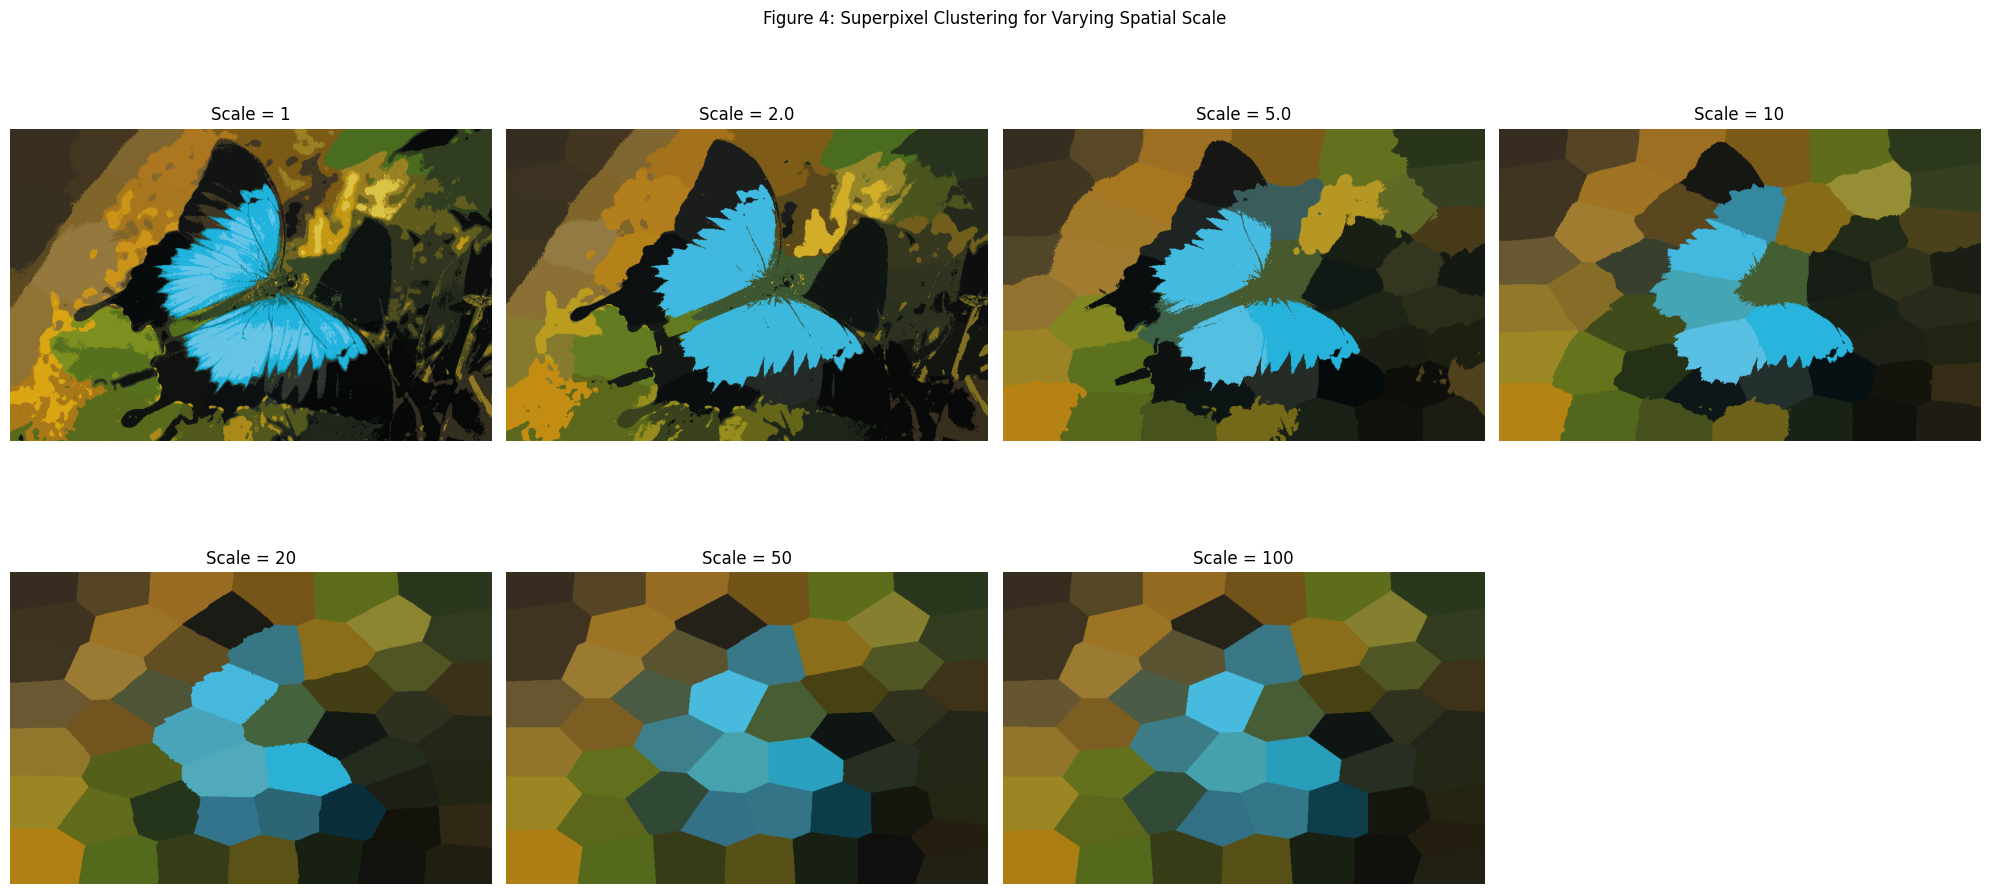

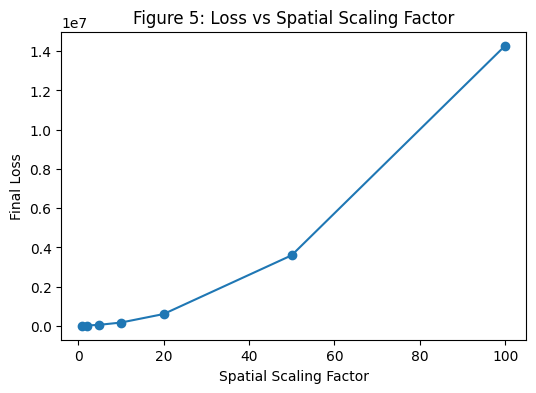

In [36]:
# Figure 4: Superpixel results across a wide range of spatial scaling factors
# Low scale = colour dominates; high scale = position dominates
scaling = [1, 2.0, 5.0, 10, 20, 50, 100]
final_losses = []

n_cols = 4
n_rows = (len(scaling) + n_cols - 1) // n_cols  # ceiling division to fit all panels
plt.figure(figsize=(20, n_rows * 5))
for i, spatial_scale in enumerate(scaling):
    losses, cluster_img, quant_img = kmeans_superpixels(im, iters=15, K=50, plot=False, spatial_scaling=spatial_scale)
    final_losses.append(losses[-1])
    plt.subplot(n_rows, n_cols, i+1)
    plt.imshow(quant_img)
    plt.title(f"Scale = {spatial_scale}")
    plt.axis("off")
plt.suptitle("Figure 4: Superpixel Clustering for Varying Spatial Scale")
plt.tight_layout()
plt.show()

# Figure 5: Loss vs spatial scaling — loss rises with scale as colour fit worsens
plt.figure(figsize=(6, 4))
plt.plot(scaling, final_losses, marker="o")
plt.xlabel("Spatial Scaling Factor")
plt.ylabel("Final Loss")
plt.title("Figure 5: Loss vs Spatial Scaling Factor")
plt.show()


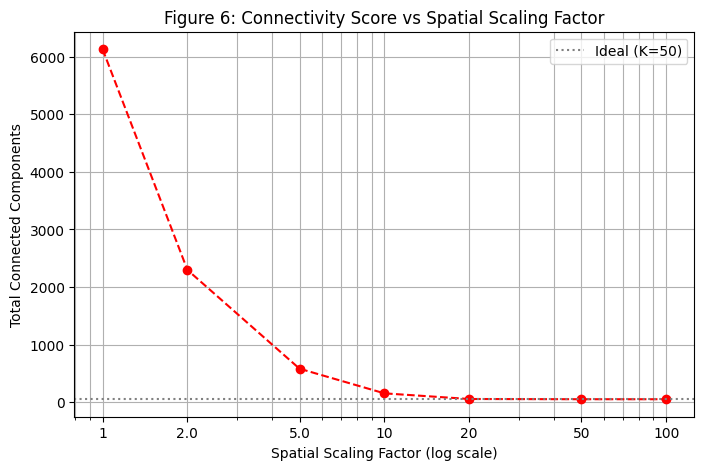

In [37]:
from scipy.ndimage import label

def connectivity_score(cluster_img, K):
    """Count total connected components across all clusters; ideal = K (one per cluster)."""
    total_components = 0
    for k in range(K):
        mask = (cluster_img == k)
        _, num_components = label(mask)
        total_components += num_components
    return total_components

# Figure 6: Connectivity score vs spatial scaling
# Match the same scale values used in Figure 4 for consistency
scales = [1, 2.0, 5.0, 10, 20, 50, 100]
scores = []
test_K = 50

for s in scales:
    losses, cluster_img, quant_img = kmeans_superpixels(im, iters=15, K=test_K, spatial_scaling=s)
    scores.append(connectivity_score(cluster_img, test_K))

plt.figure(figsize=(8, 5))
plt.plot(scales, scores, marker="o", color="red", linestyle="--")
plt.axhline(y=test_K, color="grey", linestyle=":", label=f"Ideal (K={test_K})")
plt.xscale("log")  # log x-axis because scale values span two orders of magnitude
plt.xticks(scales, labels=[str(s) for s in scales])
plt.xlabel("Spatial Scaling Factor (log scale)")
plt.ylabel("Total Connected Components")
plt.title("Figure 6: Connectivity Score vs Spatial Scaling Factor")
plt.legend()
plt.grid(True, which="both")
plt.show()


As shown in Figure 6, a scaling factor of 20 is the point where the connectivity score first approaches the ideal of K=50 (one connected component per superpixel). Below this value, colour similarity dominates and superpixels fragment across spatially distant regions. Above it, spatial proximity dominates and superpixels become coarse blocks that ignore colour boundaries. A scaling factor of 20 is therefore used for subsequent tasks as the best trade-off between colour fidelity and spatial continuity.

## Task 3: Region proposal

Segment your image into 10 superpixels. Then find the locations of the top left pixel and bottom right pixel in a superpixel, and use this information and the cv2.rectangle function to draw rectangles (regions) on the original image for each superpixel.


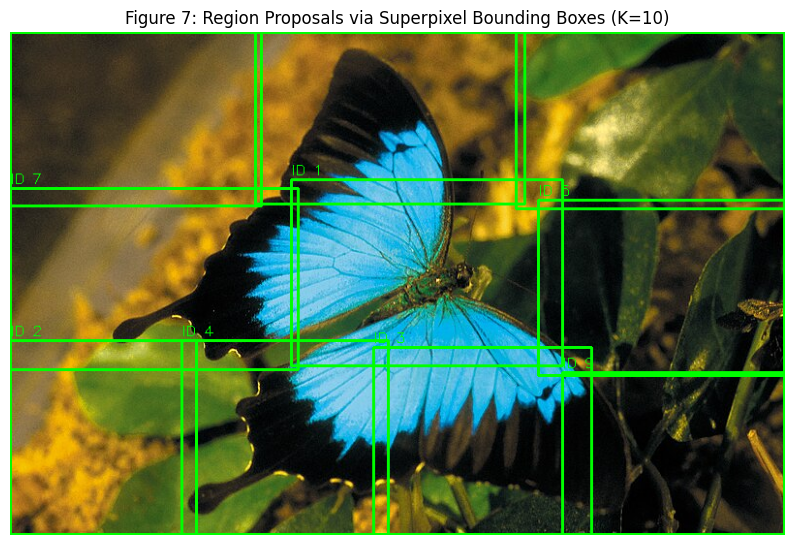

In [38]:
# Figure 7: Region proposals — bounding box of each superpixel drawn on the original image
K_test = 10
losses, cluster_idx_image, quantised_image = kmeans_superpixels(im, iters=15, K=K_test, plot=False, spatial_scaling=20)

rect_image = (im * 255).astype(np.uint8).copy()

for k in range(K_test):
    coords = np.argwhere(cluster_idx_image == k)  # all (row, col) = (y, x) for this superpixel
    if len(coords) > 0:
        y_min, x_min = coords.min(axis=0)  # top-left corner
        y_max, x_max = coords.max(axis=0)  # bottom-right corner
        cv2.rectangle(rect_image, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)
        cv2.putText(rect_image, f"ID {k}", (x_min, max(y_min - 5, 0)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

plt.figure(figsize=(10, 8))
plt.imshow(rect_image)
plt.title(f"Figure 7: Region Proposals via Superpixel Bounding Boxes (K={K_test})")
plt.axis("off")
plt.show()


## Task 4: Discussion

Write a brief report (max 600 words) discussing explaining your implementation
and results. Explain your reasoning by referencing the intermediate result figures
you generated.


The image was first converted from BGR to RGB format and normalised to the range [0,1]. It was then reshaped into an N×3 matrix where each row represents a pixel in RGB space. K-means clustering was applied by iteratively assigning pixels to the nearest centroid and updating centroid positions.

#### Figure 1: Quantised images for varying K

From the results, increasing K improved colour fidelity, with noticeable improvements from K=2 to K=8. Beyond this, gains diminished, as seen in the visual comparison where K=16 and K=32 showed only minor improvements over K=8.

#### Figure 2: Loss vs K (Elbow Method)

The loss curve demonstrated a clear elbow around K=8. This indicates a point of diminishing returns where additional clusters do not significantly reduce reconstruction error. Therefore, K=8 was selected as a reasonable trade-off between image quality and model complexity.

#### Figure 3: K-means Convergence (K=8)

K-means was run for 15 iterations. The convergence plot shows that the loss drops sharply in the first 5–6 iterations and plateaus thereafter, confirming the algorithm has effectively converged well within this budget. Running beyond 15 iterations yields negligible reduction in loss while linearly increasing computation time, making 15 a practical upper bound for this image size.

To enforce spatial coherence, pixel coordinates were incorporated into the feature space as:

[R,G,B,x,y]

where spatial coordinates were scaled by a factor controlling the trade-off between colour similarity and spatial proximity.

#### Figure 4: Superpixel Clustering for Varying Spatial Scale

Several scaling factors were tested (1 to 100). Results showed:

* Low scaling (1–5): clustering dominated by colour, producing fragmented regions with poor spatial continuity.
* Moderate scaling (≈10–20): produced compact and coherent superpixels while preserving object boundaries.
* High scaling (50–100): overly emphasised spatial proximity, leading to block-like regions that ignored colour structure.

#### Figure 5: Loss vs Spatial Scaling

The loss increased dramatically as scaling increased, but this metric alone was insufficient for evaluation, as it does not capture connectivity or perceptual quality.

#### Figure 6: Connectivity Score vs Scaling

A connectivity metric (number of connected components per cluster) was used to evaluate superpixel integrity. The optimal region occurred around a scaling factor of approximately 20, where clusters remained largely connected without overly distorting colour boundaries.

Figure 7 displays bounding boxes over the superpixels using a spatial scaling factor of 20. The overlap between neighbouring boxes indicates that the superpixel boundaries are not perfectly crisp, reflecting some softness in the clustering and limited enforcement of strict spatial separation.

The experiments demonstrate that:

* K≈8 is optimal for colour-based compression using K-means, based on the elbow method.
* Incorporating spatial features significantly improves segmentation quality by enforcing locality.
* A spatial scaling factor around 20 provides the best trade-off between colour fidelity and superpixel continuity, as supported by both connectivity metrics and visual inspection.

While K-means produces reasonable superpixels, it does not guarantee full connectivity, motivating more advanced methods such as SLIC for future improvement.